In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal
from langchain_openai import ChatOpenAI

f:\Langgraph\myenv\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [ ]:
class CategoryEmail(TypedDict):
    job_category: False
    meeting_category: False
    spam_category: False
    bank_category: False
    email: str

In [3]:
model = ChatOpenAI(model="gpt-3.5-turbo", temperature=0.9)

In [18]:
def job_category(state: CategoryEmail) -> CategoryEmail:
    return {"job_category": True}
    
def meeting_category(state: CategoryEmail) -> CategoryEmail:
    return {"meeting_category": True}

def spam_category(state: CategoryEmail) -> CategoryEmail:
    return {"spam_category": True}

def bank_category(state: CategoryEmail) -> CategoryEmail:
    return {"bank_category": True}

In [19]:
def condition_check(state: CategoryEmail) -> Literal["job_category", "meeting_category", "spam_category", "bank_category"]:
    prompt = f"""
    Classify the following email into one of the following categories: job_category, meeting_category, spam_category, bank_category.
    Email: {state['email']}
    """
    response = model.invoke(prompt)
    print(response)
    if "job" in response.content.lower():
        return "job_category"
    elif "meeting" in response.content.lower():
        return "meeting_category"
    elif "spam" in response.content.lower():
        return "spam_category"
    return "bank_category"

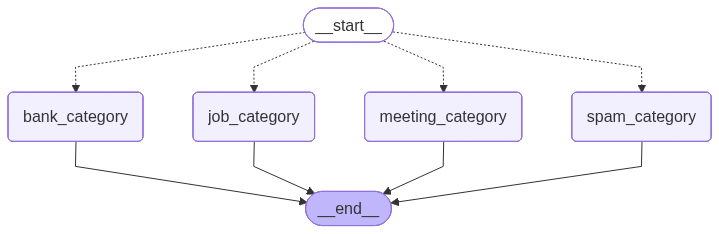

In [22]:
graph = StateGraph(CategoryEmail)

graph.add_node("job_category", job_category)
graph.add_node("meeting_category", meeting_category)
graph.add_node("spam_category", spam_category)
graph.add_node("bank_category", bank_category)


graph.add_conditional_edges(START, condition_check)
graph.add_edge("job_category", END)
graph.add_edge("meeting_category", END)
graph.add_edge("spam_category", END)
graph.add_edge("bank_category", END)

workflow = graph.compile()
workflow

In [23]:
workflow.invoke({"email": "You have a meeting scheduled for tomorrow at 10 AM."})

content='meeting_category' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 2, 'prompt_tokens': 49, 'total_tokens': 51, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DfqHrOjQ03tqSFkHuExIm3HZj2U5p', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019e2c9a-f1c0-7d91-912f-7ec57e547a8b-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 49, 'output_tokens': 2, 'total_tokens': 51, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}


{'meeting_category': True,
 'email': 'You have a meeting scheduled for tomorrow at 10 AM.'}

In [24]:
workflow.invoke({"email": "You have selected for next round of an Interview."})

content='job_category' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 2, 'prompt_tokens': 47, 'total_tokens': 49, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DfqHz6YBxngKUWVJEv5DaffCeUNZ6', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019e2c9b-135d-7762-bfad-b446812cd005-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 47, 'output_tokens': 2, 'total_tokens': 49, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}


{'job_category': True,
 'email': 'You have selected for next round of an Interview.'}

In [25]:
workflow.invoke({"email": "You got 1 CR lottary. Fill this given details to claim your prize."})

content='spam_category' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 2, 'prompt_tokens': 55, 'total_tokens': 57, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DfqI3ePfqIBzBgcvo6GTUj3qbkCYI', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019e2c9b-20a7-7922-9c46-64eb94d1eb62-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 55, 'output_tokens': 2, 'total_tokens': 57, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}


{'spam_category': True,
 'email': 'You got 1 CR lottary. Fill this given details to claim your prize.'}

In [26]:
workflow.invoke({"email": "10k Money is debitated from your HDFC bank account. Please check your account for more details."})

content='bank_category' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 2, 'prompt_tokens': 59, 'total_tokens': 61, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DfqI5rIsFvv82VohP6wzFfB886OXs', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019e2c9b-2a59-7303-9cea-16b2c9fd7406-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 59, 'output_tokens': 2, 'total_tokens': 61, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}


{'bank_category': True,
 'email': '10k Money is debitated from your HDFC bank account. Please check your account for more details.'}